# Advanced Statistical Inference -- Bayesian Neural Networks

**Hardware note:** This notebook is computationally intensive (neural networks, MCMC, VI).
For best performance, use a GPU:
- **Google Colab:** Runtime > Change runtime type > GPU
- **Local:** Install CUDA and run on a GPU machine

**No code changes required!** JAX automatically accelerates computations on GPU when available.
Just write standard Python/NumPy code and JAX handles the hardware acceleration behind the scenes.
This is one of the key advantages of JAX over NumPy.

## Tools Overview

- **JAX**: High-performance numerical computing library with automatic differentiation (`jax.grad`, `jax.jit`)
- **NumPyro**: Probabilistic programming built on JAX, similar to PyTorch's Pyro
- **Flax**: Neural network library for JAX

**Note:** Check the tutorial on JAX if you haven't done so already.


In this lab, we will explore **Bayesian neural networks** (BNNs) for uncertainty quantification in classification.
We will compare different inference methods:
- **Variational Inference (VI)** -- approximate posterior with a parametric family
- **MCMC** -- exact posterior sampling (when tractable)
- **MAP estimation** -- point estimate

We focus on a 2D binary classification task (the moons dataset) to enable easy visualization, and then we will analyze a real-world dataset (MNIST) to see how these methods scale to higher dimensions.

## Why Bayesian Neural Networks?

Standard neural networks produce point estimates of the weights, leading to:
- **Overconfidence**: the network assigns high confidence even far from training data
- **No uncertainty quantification**: we cannot distinguish epistemic (model) and aleatoric (data) uncertainty

A BNN places a prior $p(\mathbf{w})$ over the weights and computes the posterior $p(\mathbf{w} | \mathbf{X}, \mathbf{y})$.
The posterior is intractable for neural networks, so we use approximate inference.

In [2]:
try:
    import numpyro
except ImportError:
    import os

    print("Installing numpyro...")
    os.system("pip install numpyro")
    import numpyro

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from functools import partial
from matplotlib import rc
from tqdm.notebook import tqdm

rc("figure", **{"dpi": 200})
rc(
    "axes",
    **{"spines.right": False, "spines.top": False, "xmargin": 0.0, "ymargin": 0.05},
)

Installing numpyro...


---
# GPU Check

Check if JAX can see a GPU and print device info.

In [3]:
# Check GPU availability
cpu_devices = jax.devices("cpu")

try:
    print("=" * 50)
    print("Device Information")
    print("=" * 50)
    gpu_available = jax.devices("gpu")
    for gpu in gpu_available:
        print(f"  - {gpu}")
except:
    print("  WARNING: No GPU detected!")
    print()
    print("  This notebook is computationally intensive.")
    print("  Without a GPU, training will be significantly slower.")
    print()
    print("  To enable GPU on Google Colab:")
    print("    1. Runtime > Change runtime type")
    print("    2. Select 'T4 GPU' (or any GPU) as hardware accelerator")
    print("    3. Runtime > Run all (or restart runtime first)")
    print()
    print(f"  Falling back to {len(cpu_devices)} CPU(s)")

print(f"\nDefault device: {jax.default_backend()}")
print("=" * 50)

Device Information
  - cuda:0

Default device: gpu


---
# Part 1: Data -- Two Moons

A classic 2D binary classification benchmark where a linear classifier cannot separate the classes.

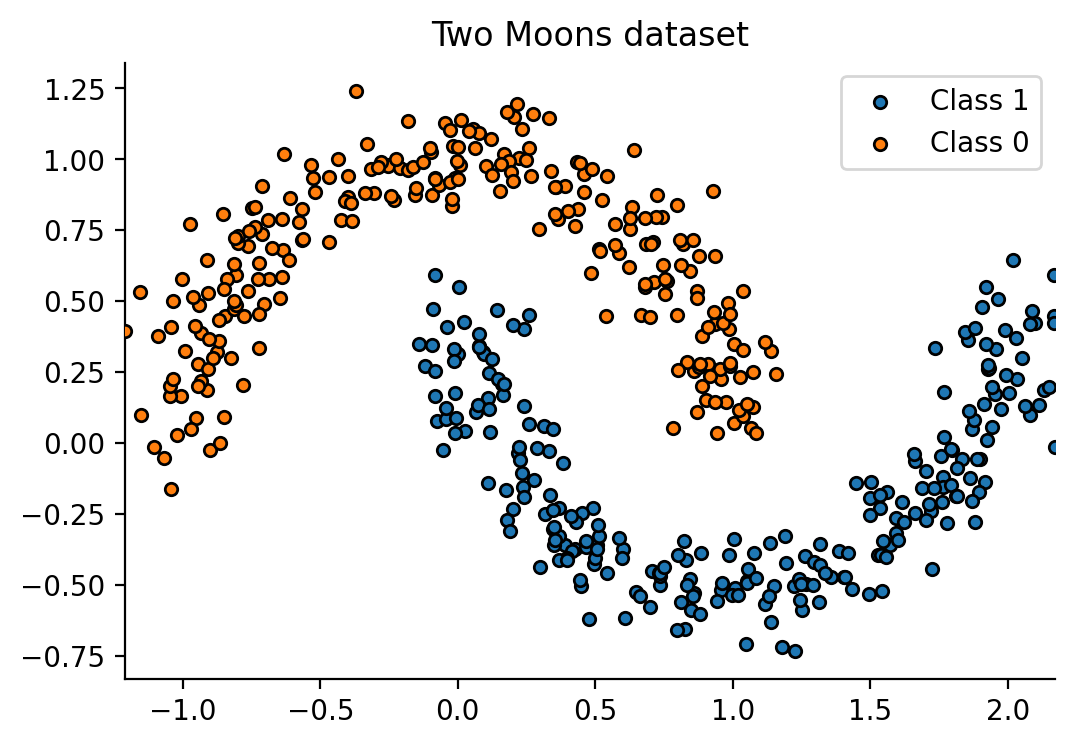

In [4]:
from sklearn.datasets import make_moons

np.random.seed(42)
X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
X = jnp.array(X, dtype=jnp.float32)
y = jnp.array(y, dtype=jnp.float32)


def plot_data(X, y, ax):
    mask = y == 1
    config = dict(edgecolor="black", linewidth=1, zorder=10, s=20)
    ax.scatter(*X[mask].T, label="Class 1", facecolor="tab:blue", **config)
    ax.scatter(*X[~mask].T, label="Class 0", facecolor="tab:orange", **config)


def get_grid(xlim=(-2, 3), ylim=(-1.5, 2), N=100):
    x_grid = np.linspace(*xlim, N)
    y_grid = np.linspace(*ylim, N)
    xx, yy = np.meshgrid(x_grid, y_grid)
    X_plot = np.vstack((xx.flatten(), yy.flatten())).T
    return xx, yy, X_plot


fig, ax = plt.subplots(figsize=[6, 4])
plot_data(X, y, ax)
ax.set_title("Two Moons dataset")
ax.legend()
plt.show()

---
# Part 2: Model Definition with Flax + NumPyro

We define a 2-layer MLP using Flax, then use NumPyro to make it Bayesian.

In [4]:
import numpyro
import numpyro.distributions as dist
from numpyro.contrib.module import random_flax_module
from flax import linen as nn


class MLP(nn.Module):
    """2-hidden-layer MLP for binary classification."""

    hidden_dim: int = 32
    output_dim: int = 1

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(self.hidden_dim, use_bias=True, name="layer1")(x)
        x = nn.relu(x)

        x = nn.Dense(self.hidden_dim, use_bias=True, name="layer2")(x)
        x = nn.relu(x)

        x = nn.Dense(self.output_dim, use_bias=True, name="layer3")(x)

        return x.squeeze(-1)

In [5]:
def bnn_model(X, y=None, hidden_dim=32):
    """
    Bayesian neural network model using NumPyro + Flax.
    """
    N, D = X.shape
    flax_nn = MLP(hidden_dim=hidden_dim, output_dim=1)

    nn_module = random_flax_module(
        "nn",
        flax_nn,
        prior=dist.Normal(0, 1),
        input_shape=(1, D),
    )
    logits = nn_module(X)
    probs = jax.nn.sigmoid(logits)
    numpyro.deterministic("probs", probs)

    with numpyro.plate("data", N):
        numpyro.sample("obs", dist.Bernoulli(probs=probs), obs=y)


# Test that the model runs
print("Testing model...")
test_model = MLP(hidden_dim=32, output_dim=1)
test_params = test_model.init(jax.random.key(0), jnp.ones((1, 2)))
print(f"Number of parameters: {sum(p.size for p in jax.tree.leaves(test_params))}")

Testing model...
Number of parameters: 1185


**Understanding the Model Architecture**

The MLP has two hidden layers with ReLU activations:
- **Layer 1**: 2 inputs → 32 outputs
- **Layer 2**: 32 → 32
- **Layer 3**: 32 → 1

The `bnn_model` function wraps the Flax MLP in a NumPyro model:
- `random_flax_module`: Creates a stochastic neural network where weights are sampled from the prior
- `numpyro.plate("data", N)`: Vectorizes the likelihood over N data points (observations are independent given weights)
- `dist.Bernoulli(probs=probs)`: Likelihood for binary classification

**Questions:**
1. Why do we use `dist.Normal(0, 1)` as the prior? What does this imply about our assumptions on the weights?
2. How many parameters does the network have? Break this down by layer.
3. What does `jax.nn.sigmoid` do? Why do we need it?

1. We use dist.Normal(0, 1) as the prior since it specifies a standard normal distribution with mean 0 and standard deviation. This implies a weak informative prior assumption that the parameters are centered around 0 with moderate variability, allowing the data to strongly influence the posterior. This helps avoid overfitting while enabling regularization.
2. The network has 1185 parameters
- Layer 1 (input: 2 → hidden: 32): 64 weights (2×32) + 32 biases = 96 parameters
- Layer 2 (hidden: 32 → hidden: 32): 1,024 weights (32×32) + 32 biases = 1,056 parameters
- Layer 3 (hidden: 32 → output: 1): 32 weights (32×1) + 1 bias = 33 parameters
3. jax.nn.signmoid applies the sigmoid activation function which maps any input into a value between 0 and 1. It's needed here because the network outputs raw logits but the Bernouli likelihood requires probabilities [0,1] for binary classification.

---
# Part 3: Inference Functions

We define helper functions to run different inference methods.
Read carefully to understand how variational inference and MCMC are implemented in NumPyro.


In [1]:
from numpyro.infer import SVI, Trace_ELBO, MCMC, NUTS
from numpyro.infer.autoguide import (
    AutoDiagonalNormal,
    AutoMultivariateNormal,
    AutoDelta,
)


def run_inference(
    method, model, X, y, rng_key=0, num_steps=10000, hidden_dim=32, **kwargs
):
    """
    Unified interface for running different inference methods.

    Args:
        method: One of 'map', 'vi_diagonal', 'vi_full', 'mcmc'
        model: NumPyro probabilistic model
        X: Input data (N x D)
        y: Target labels (N,)
        rng_key: Random key for reproducibility
        num_steps: Number of optimization steps (VI) or warmup steps (MCMC)
        hidden_dim: Hidden dimension for the neural network

    Returns:
        Dictionary containing:
        - 'method': 'vi' or 'mcmc'
        - For VI: 'guide', 'params', 'losses', 'vi_method'
        - For MCMC: 'samples'
    """
    if isinstance(rng_key, int):
        rng_key = jax.random.key(rng_key)

    if method.startswith("vi_") or method == "map":
        return _run_vi(method, model, X, y, rng_key, num_steps, hidden_dim, **kwargs)
    elif method == "mcmc":
        return _run_mcmc(
            model,
            X,
            y,
            rng_key,
            num_warmup=num_steps,
            num_samples=200,
            hidden_dim=hidden_dim,
        )
    else:
        raise ValueError(f"Unknown method: {method}")


def _run_vi(vi_method, model, X, y, rng_key, num_steps, hidden_dim, lr=1e-3, **kwargs):
    """
    Run Stochastic Variational Inference with different guide types.

    The guide defines the variational family q(w; theta):
    - AutoDiagonalNormal: Mean-field approximation (independent Gaussian per weight)
    - AutoMultivariateNormal: Full covariance Gaussian (captures weight correlations)
    - AutoDelta: Point estimate (MAP estimation, no uncertainty)

    Args:
        vi_method: One of 'vi_diagonal', 'vi_full', 'map'
        model: The probabilistic model p(y|X,w)p(w)
        X, y: Training data
        rng_key: Random key
        num_steps: Optimization iterations
        hidden_dim: Network hidden dimension
        lr: Learning rate for Adam optimizer

    Returns:
        Dictionary with VI results and trained parameters
    """
    # Map method name to NumPyro guide class
    guide_map = {
        "vi_diagonal": AutoDiagonalNormal,  # Mean-field: ~2D parameters per weight
        "vi_full": AutoMultivariateNormal,  # Full covariance: O(D^2) parameters
        "map": AutoDelta,  # Point estimate: no uncertainty
    }

    # Initialize the variational guide (approximating distribution q(w))
    guide = guide_map[vi_method](model)

    # Set up SVI: maximize ELBO = E_q[log p(D|w)] - KL(q||p)
    optimizer = numpyro.optim.Adam(lr)
    svi = SVI(model, guide, optimizer, Trace_ELBO(num_particles=1))

    print(f"Training with {vi_method.upper()}...")
    svi_result = svi.run(
        rng_key,
        num_steps=num_steps,
        X=X,
        y=y,
        hidden_dim=hidden_dim,
        progress_bar=True,
    )

    return {
        "method": "vi",
        "vi_method": vi_method,
        "guide": guide,
        "params": svi_result.params,  # Variational parameters (means, stds)
        "losses": svi_result.losses,  # ELBO trajectory for monitoring
    }


def _run_mcmc(
    model, X, y, rng_key, num_warmup=1000, num_samples=200, hidden_dim=32, **kwargs
):
    """
    Run Markov Chain Monte Carlo sampling using the No-U-Turn Sampler (NUTS).

    NUTS is a Hamiltonian Monte Carlo sampler that:
    1. Uses gradient information for efficient exploration
    2. Automatically determines trajectory length (no manual tuning)
    3. Samples from the exact posterior (given enough samples/warmup)

    Args:
        model: The probabilistic model
        X, y: Training data
        rng_key: Random key
        num_warmup: Number of warmup/burn-in iterations (step size tuning + burn-in)
        num_samples: Number of posterior samples to keep (before thinning)
        hidden_dim: Network hidden dimension

    Returns:
        Dictionary with posterior samples
    """
    # NUTS kernel: uses gradient-based proposals via Hamiltonian dynamics
    kernel = NUTS(model, max_tree_depth=7)  # max_tree_depth limits leapfrog steps

    mcmc = MCMC(
        kernel,
        num_warmup=num_warmup,  # Burn-in + step size adaptation
        num_samples=num_samples * 10,  # Total samples before thinning
        progress_bar=True,
        thinning=10,  # Keep every 10th sample (reduces autocorrelation)
    )

    print("Running MCMC with NUTS...")
    mcmc.run(rng_key, X=X, y=y, hidden_dim=hidden_dim)

    return {
        "method": "mcmc",
        "samples": mcmc.get_samples(),  # Dict of {parameter_name: array of samples}
        "losses": None,  # No loss trajectory for MCMC
    }

ModuleNotFoundError: No module named 'numpyro'

In [ ]:
from numpyro.infer import Predictive


def make_predictions(model, X_test, result, n_samples=200, rng_key=1, hidden_dim=32):
    """
    Generate predictions using posterior samples.

    This function:
    1. Draws weight samples from the posterior (VI guide or MCMC)
    2. Runs forward pass with each weight sample
    3. Collects predictions to compute mean and variance

    Args:
        model: NumPyro model (used for Predictive inference)
        X_test: Test inputs (N x D)
        result: Output from run_inference containing posterior info
        n_samples: Number of samples to draw (for VI; MCMC uses stored samples)
        rng_key: Random key
        hidden_dim: Network hidden dimension

    Returns:
        probs: All predicted probabilities (n_samples x N), for uncertainty estimation
        mean_probs: Mean predicted probability per input (N,), for point prediction
    """
    if isinstance(rng_key, int):
        rng_key = jax.random.key(rng_key)

    # Step 1: Get posterior weight samples
    # For VI: sample from the learned variational distribution q(w)
    # For MCMC: use the pre-computed chain samples
    if result["method"] == "vi":
        posterior_samples = result["guide"].sample_posterior(
            rng_key,
            result["params"],
            sample_shape=(n_samples,),
            X=X_test,
            hidden_dim=hidden_dim,
        )
    elif result["method"] == "mcmc":
        posterior_samples = result["samples"]
    else:
        raise ValueError(f"Unknown method: {result['method']}")

    # Step 2: Create Predictive object that runs the model with posterior weights
    # This draws n_samples forward passes, each with different weights
    predictive = Predictive(
        model,
        posterior_samples=posterior_samples,
        return_sites=["probs"],  # Only extract probabilities, not logits
    )

    # Step 3: Run all samples through the model
    predictions = predictive(rng_key, X=X_test, hidden_dim=hidden_dim)

    # Step 4: Reshape and compute statistics
    # predictions["probs"] has shape (n_samples, N), transpose to (N, n_samples)
    probs = predictions["probs"].T

    # Mean probability across samples (Bayesian model averaging)
    mean_probs = jnp.mean(probs, axis=1)

    return probs, mean_probs

**Deep Dive: Inference Methods**

### Variational Inference (VI)
VI approximates the intractable posterior $p(\mathbf{w} | \mathcal{D})$ with a simpler distribution $q(\mathbf{w}; \nu)$.
We optimize $\nu$ to minimize the KL divergence $KL(q(\mathbf{w}; \nu) || p(\mathbf{w} | \mathcal{D}))$.

This is equivalent to maximizing the **ELBO** (Evidence Lower Bound):
$$\mathcal{L}(\nu) = \mathbb{E}_{q(\mathbf{w}; \nu)}[\log p(\mathcal{D} | \mathbf{w})] - KL(q(\mathbf{w}; \nu) || p(\mathbf{w}))$$

The first term is the expected log-likelihood (reconstruction), the second is the prior regularization.

### Guides in NumPyro
NumPyro provides "guides" which are parametric families for the variational distribution:
- `AutoDiagonalNormal`: Mean-field approximation $q(\mathbf{w}) = \prod_d \mathcal{N}(\mu_d, \sigma_d^2)$
- `AutoMultivariateNormal`: Full covariance $q(\mathbf{w}) = \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$
- `AutoDelta`: Point estimate (no uncertainty, just maximum a posteriori)

### MCMC with NUTS
NUTS (No-U-Turn Sampler) draws samples from the exact posterior using Hamiltonian dynamics.
- Warmup: Adaptive step size tuning, burn-in period
- Thinning: Keep every k-th sample to reduce autocorrelation
- Trade-off: More accurate but much slower than VI

### Predictions
Uses `numpyro.infer.Predictive` to:
1. Sample weights from the posterior
2. Run forward pass for each sample
3. Collect predictions to compute whatever we want

**Questions about inference methods:**
1. What is the difference between `DiagonalNormal` and `MultivariateNormal`? How does this affect the number of parameters and the expressiveness of the variational distribution?
2. What does the `AutoDelta` correspond to conceptually?

### 1. MAP Estimation

In [ ]:
result_map = run_inference(
    method="map",
    model=bnn_model,
    X=X,
    y=y,
    rng_key=0,
    num_steps=10000,
    hidden_dim=32,
)

In [ ]:
# Plot training loss
if result_map["losses"] is not None:
    fig, ax = plt.subplots(figsize=[6, 3])
    ax.plot(result_map["losses"])
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss (negative log posterior)")
    ax.set_title("MAP Training Loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Understanding the Loss Curve**

The loss shown is the negative ELBO. With `AutoDelta` guide, this simplifies to:
$$-\log p(\mathbf{y} | \mathbf{X}, \mathbf{w}_{MAP}) - \log p(\mathbf{w}_{MAP})$$

i.e., negative log posterior (log-likelihood + log prior).


**Questions after running MAP:**
1. Does the loss converge? Approximately how many iterations does it take?
2. What is MAP optimizing? What does "MAP" stand for? (Maximum A Posteriori)
3. Why does MAP give a point estimate rather than a distribution?

### 2. VI with Diagonal Covariance

In [ ]:
result_vi_diag = run_inference(
    method="vi_diagonal",
    model=bnn_model,
    X=X,
    y=y,
    rng_key=0,
    num_steps=10000,
    hidden_dim=32,
)

In [ ]:
# Plot training loss
if result_vi_diag["losses"] is not None:
    fig, ax = plt.subplots(figsize=[6, 3])
    ax.plot(result_vi_diag["losses"])
    ax.set_xlabel("Iteration")
    ax.set_ylabel("ELBO (negative)")
    ax.set_title("VI Diagonal Training Loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Why the Different Curves?**

The ELBO curve shows the same quantity being optimized (negative log posterior) but:
- **MAP**: Optimizes only the mean, no uncertainty
- **VI**: Optimizes both mean AND variance


**Questions after running VI Diagonal:**
1. How does the ELBO curve differ from the MAP loss curve?
2. What does "diagonal" mean in this context?
3. Why is the curve more noisy than before?

### 3. VI with Full Covariance

In [ ]:
result_vi_full = run_inference(
    method="vi_full",
    model=bnn_model,
    X=X,
    y=y,
    rng_key=0,
    num_steps=20000,
    hidden_dim=32,
)

In [ ]:
# Plot training loss
if result_vi_full["losses"] is not None:
    fig, ax = plt.subplots(figsize=[6, 3])
    ax.plot(result_vi_full["losses"])
    ax.set_xlabel("Iteration")
    ax.set_ylabel("ELBO (negative)")
    ax.set_title("VI Full Training Loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Why Full Covariance is Computationally Expensive**

Full covariance requires learning a complete covariance matrix:
- Number of parameters: $D + D(D-1)/2 \approx D^2/2$ (where D = number of weights)
- For 1185 weights: ~702,000 parameters (vs 1185 for diagonal)
- Per-step computation is $O(D^2)$ instead of $O(D)$


**Questions after running VI Full:**
1. Compare training time with VI Diagonal. How much slower is full covariance?
2. What is the computational cost difference between diagonal and full covariance?
3. Why full covariance has $D+D(D-1)/2$ parameters? Where dose this formula come from?

### 4. MCMC with NUTS

In [ ]:
result_mcmc = run_inference(
    method="mcmc",
    model=bnn_model,
    X=X,
    y=y,
    rng_key=0,
    num_steps=1000,
    hidden_dim=32,
)

In [ ]:
# Setup grid for predictions
xx, yy, X_grid = get_grid((-2, 3), (-1.5, 2), N=80)

**MCMC Parameters Explained**

- `num_warmup=1000`: Number of iterations to tune step size and burn in
- `num_samples=2000`: Actual samples kept (200 samples × 10 thinning)
- `thinning=10`: Keep every 10th sample to reduce autocorrelation


**Questions after running MCMC:**
1. How long does MCMC take compared to VI? Why?
2. What is the "warmup" phase doing?
3. Is MCMC sampling from the true posterior or an approximation?

### Generate Predictions

In [ ]:
# MAP predictions
probs_map, mean_probs_map = make_predictions(
    model=bnn_model,
    X_test=X_grid,
    result=result_map,
    n_samples=200,
    rng_key=1,
    hidden_dim=32,
)

# VI diagonal predictions
probs_vi_diag, mean_probs_vi_diag = make_predictions(
    model=bnn_model,
    X_test=X_grid,
    result=result_vi_diag,
    n_samples=200,
    rng_key=1,
    hidden_dim=32,
)

# VI full predictions
probs_vi_full, mean_probs_vi_full = make_predictions(
    model=bnn_model,
    X_test=X_grid,
    result=result_vi_full,
    n_samples=200,
    rng_key=1,
    hidden_dim=32,
)

# MCMC predictions
probs_mcmc, mean_probs_mcmc = make_predictions(
    model=bnn_model,
    X_test=X_grid,
    result=result_mcmc,
    n_samples=200,
    rng_key=1,
    hidden_dim=32,
)

In [ ]:
def plot_decision_boundary(xx, yy, P, ax, title=""):
    P = P.reshape(*xx.shape)
    levels = [0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1]
    ax.contour(xx, yy, P, levels, colors="k", linewidths=1.4, zorder=100)
    ax.contourf(xx, yy, P, levels, cmap="RdBu_r", alpha=0.6)
    ax.set_title(title)

In [ ]:
# Plot all methods in 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=[12, 10])
axes = axes.flatten()

predictions = [
    (mean_probs_map, "MAP"),
    (mean_probs_vi_diag, "VI DIAGONAL"),
    (mean_probs_vi_full, "VI FULL"),
    (mean_probs_mcmc, "MCMC"),
]

for i, (mean_probs, name) in enumerate(predictions):
    plot_decision_boundary(xx, yy, mean_probs, axes[i], name)
    plot_data(X, y, axes[i])

plt.suptitle("Comparison of Inference Methods", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Questions about decision boundaries:**
1. How does the decision boundary differ between MAP and the Bayesian methods?
2. Which regions show the most difference between methods?
3. Is the mean prediction from VI similar to MAP? Why or why not?
4. Compare the smoothness of decision boundaries. What might cause roughness?
5. In which regions do you see the biggest difference between MAP and VI/MCMC means?

---
# Part 4: Uncertainty Decomposition

Bayesian neural networks naturally capture two types of uncertainty:

**Epistemic uncertainty** (model uncertainty) arises from not knowing the model parameters. It is:
- **High** in regions far from training data
- **Low** in regions where we have abundant data
- **Captured** by the variance across posterior samples
- Can be **reduced** by collecting more data

**Aleatoric uncertainty** (data uncertainty) is inherent noise in the data. It is:
- **Independent** of training data location
- **Cannot be reduced** by collecting more data
- **Captured** by the average entropy within each posterior sample

This decomposition is crucial for:
- **Active learning**: Which samples to label next? (high epistemic = learn more)
- **Out-of-distribution detection**: OOD data shows high epistemic uncertainty
- **Risk-sensitive applications**: Know when to defer to humans

## Information-Theoretic Decomposition

The total predictive uncertainty decomposes as:

$$\underbrace{H[y \mid \mathbf{x}]}_{\text{Total}} = \underbrace{I[w; y \mid \mathbf{x}]}_{\text{Epistemic}} + \underbrace{\mathbb{E}_{p(w \mid \mathcal{D})}[H[y \mid \mathbf{x}, w]]}_{\text{Aleatoric}}$$

For **binary classification** with Bernoulli likelihood:
- **Total entropy**: $H_{\text{total}} = -\bar{p} \log \bar{p} - (1-\bar{p}) \log(1-\bar{p})$
- **Aleatoric entropy**: $\frac{1}{S} \sum_{s=1}^S [-p_s \log p_s - (1-p_s) \log(1-p_s)]$
- **Epistemic**: $H_{\text{epistemic}} = H_{\text{total}} - H_{\text{aleatoric}}$

In [ ]:
def binary_entropy(p):
    """Binary entropy H(Bernoulli(p)) = -p*log(p) - (1-p)*log(1-p)."""
    p = jnp.clip(p, 1e-6, 1 - 1e-6)
    return -(p * jnp.log(p) + (1 - p) * jnp.log(1 - p))


def total_uncertainty(probs):
    """
    Total uncertainty: entropy of the mean predicted probability.
    """
    # @@ COMPLETE @@
    # mean_prob =
    # tu =
    return tu


def aleatoric_uncertainty(probs):
    """
    Aleatoric uncertainty: expected entropy across posterior samples.
    E_q[H[p(y=1|x,w)]] = average entropy for each sample
    """
    # @@ COMPLETE @@
    # entropies =
    # au =
    return au


def epistemic_uncertainty(probs):
    """Epistemic uncertainty = total - aleatoric (mutual information I[y;w|x])."""
    # @@ COMPLETE @@
    # eu =
    return eu

In [ ]:
# Visualize uncertainty decomposition for VI Diagonal
fig, axes = plt.subplots(1, 3, figsize=[15, 4])

total_unc = total_uncertainty(probs_vi_diag).reshape(*xx.shape)
aleatoric_unc = aleatoric_uncertainty(probs_vi_diag).reshape(*xx.shape)
epistemic_unc = epistemic_uncertainty(probs_vi_diag).reshape(*xx.shape)

print(f"[VI Diagonal] Max epistemic: {jnp.max(epistemic_unc):.4f}")
print(f"[VI Diagonal] Max aleatoric: {jnp.max(aleatoric_unc):.4f}")
print(f"[VI Diagonal] Max total: {jnp.max(total_unc):.4f}")

im0 = axes[0].contourf(xx, yy, epistemic_unc, levels=20, cmap="magma")
axes[0].set_title("Epistemic (model) uncertainty")
plot_data(X, y, axes[0])
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(xx, yy, aleatoric_unc, levels=20, cmap="magma")
axes[1].set_title("Aleatoric (data) uncertainty")
plot_data(X, y, axes[1])
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(xx, yy, total_unc, levels=20, cmap="magma")
axes[2].set_title("Total uncertainty")
plot_data(X, y, axes[2])
plt.colorbar(im2, ax=axes[2])

plt.suptitle("Uncertainty Decomposition (VI Diagonal)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Questions about uncertainty decomposition:**
1. Where is the **aleatoric** uncertainty highest? Why is it high there?
2. Where is the **epistemic** uncertainty highest? What does this tell us?
3. Look at the regions far from the training data. Which type of uncertainty dominates there?
4. In the region between the two moons, which type of uncertainty is higher?

In [ ]:
# Visualize uncertainty decomposition for MCMC
fig, axes = plt.subplots(1, 3, figsize=[15, 4])

total_unc = total_uncertainty(probs_mcmc).reshape(*xx.shape)
aleatoric_unc = aleatoric_uncertainty(probs_mcmc).reshape(*xx.shape)
epistemic_unc = epistemic_uncertainty(probs_mcmc).reshape(*xx.shape)

print(f"[MCMC] Max epistemic: {jnp.max(epistemic_unc):.4f}")
print(f"[MCMC] Max aleatoric: {jnp.max(aleatoric_unc):.4f}")
print(f"[MCMC] Max total: {jnp.max(total_unc):.4f}")

im0 = axes[0].contourf(xx, yy, epistemic_unc, levels=20, cmap="magma")
axes[0].set_title("Epistemic (model) uncertainty")
plot_data(X, y, axes[0])
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(xx, yy, aleatoric_unc, levels=20, cmap="magma")
axes[1].set_title("Aleatoric (data) uncertainty")
plot_data(X, y, axes[1])
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(xx, yy, total_unc, levels=20, cmap="magma")
axes[2].set_title("Total uncertainty")
plot_data(X, y, axes[2])
plt.colorbar(im2, ax=axes[2])

plt.suptitle("Uncertainty Decomposition (MCMC)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Questions comparing VI and MCMC uncertainty:**
1. How do the epistemic uncertainty maps compare between VI and MCMC?
2. Are there regions where one method shows more epistemic uncertainty than the other?
3. What does this suggest about the approximation quality of VI?
4. Which method would you trust more for safety-critical applications?

---
# Part 5: MNIST Classification with CNN

Now we scale to a real image classification task using **MNIST**.
We use a small **CNN** for better performance on images.
We'll use **stochastic VI** with minibatches for scalability.

## 5.1 Load and Visualize MNIST Data

MNIST contains 70,000 handwritten digit images (0-9), 28×28 pixels each.
We use a small subset (10000 train, 10000 test) for faster training while
still demonstrating uncertainty quantification on real data.

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load MNIST
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X_mnist = mnist.data.astype(np.float32) / 255.0  # Normalize to [0, 1]
y_mnist = mnist.target.astype(np.int32)

# Use subset for faster training
n_train = 10000
n_test = 10000
X_train, X_test, y_train, y_test = train_test_split(
    X_mnist,
    y_mnist,
    train_size=n_train,
    test_size=n_test,
    random_state=42,
    stratify=y_mnist,
)

X_train = jnp.array(X_train)
X_test = jnp.array(X_test)
y_train = jnp.array(y_train)
y_test = jnp.array(y_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Classes: {np.unique(np.array(y_train))}")

**Question:** Why do we normalize pixel values to [0, 1]? What would happen if we didn't?

In [ ]:
# Visualize some examples
fig, axes = plt.subplots(2, 5, figsize=[10, 4])
for i, ax in enumerate(axes.flat):
    ax.imshow(np.array(X_train[i]).reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {int(y_train[i])}")
    ax.axis("off")
plt.suptitle("MNIST Examples")
plt.tight_layout()
plt.show()

## 5.2 Define CNN Model with Flax

**Why CNN instead of MLP?**
- Convolutional layers exploit spatial structure: a digit is still recognizable
  regardless of where it appears in the 28×28 grid
- 3 convolutional blocks (Conv → ReLU → AvgPool) progressively increase features
- 8 → 16 → 32 channels (doubling each block)
- Final dense layers for classification

In [ ]:
class CNN(nn.Module):
    """Simple CNN for MNIST classification."""

    num_classes: int = 10

    @nn.compact
    def __call__(self, x):
        # Reshape to image format (batch, height, width, channels)
        x = x.reshape(-1, 28, 28, 1)

        # Conv block 1: 3x3 conv -> 8 filters
        x = nn.Conv(features=8, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))

        # Conv block 2: 3x3 conv -> 16 filters
        x = nn.Conv(features=16, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))

        # Conv block 3: 3x3 conv -> 32 filters
        x = nn.Conv(features=32, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))

        # Flatten and dense
        x = x.reshape(x.shape[0], -1)
        x = nn.Dense(128)(x)
        x = nn.relu(x)
        x = nn.Dense(self.num_classes)(x)

        return x


# Initialize and check model
cnn_model = CNN(num_classes=10)
dummy_input = jnp.ones((1, 784))
cnn_params = cnn_model.init(jax.random.key(0), dummy_input)
print(f"CNN parameters: {sum(p.size for p in jax.tree.leaves(cnn_params))}")

## 5.3 Define Bayesian CNN Model with NumPyro

The Bayesian CNN is identical to the deterministic CNN, but NumPyro will
place Normal(0,1) priors on ALL convolution and dense layer weights.

Key differences from BNN for binary classification:
- 10 classes instead of 2
- Logits (unnormalized) passed to distribution, not probabilities (for numerical stability)
- Cross-entropy loss implicitly computed

In [ ]:
def cnn_bnn_model(X, y=None):
    """
    Bayesian CNN model using NumPyro + Flax.
    Uses a Normal(0, 1) prior over all weights.
    """
    N, D = X.shape
    flax_cnn = CNN(num_classes=10)

    nn_module = random_flax_module(
        "cnn",
        flax_cnn,
        prior=dist.Normal(0, 1),
        input_shape=(1, D),
    )

    logits = nn_module(X)
    numpyro.deterministic("logits", logits)

    with numpyro.plate("data", N):
        numpyro.sample("obs", dist.Categorical(logits=logits), obs=y)

**Question:** What is the difference between `dist.Categorical` and `dist.Bernoulli`?
Why do we use it here instead of Bernoulli?

## 5.4 Variational Inference for MNIST


In [ ]:
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoDiagonalNormal

guide = AutoDiagonalNormal(cnn_bnn_model)
optimizer = numpyro.optim.Adam(1e-3)
svi = SVI(cnn_bnn_model, guide, optimizer, Trace_ELBO(num_particles=1))

print("Training Bayesian CNN with VI...")
svi_result = svi.run(
    jax.random.key(0),
    num_steps=10000,
    X=X_train,
    y=y_train,
    progress_bar=True,
)

In [ ]:
fig, ax = plt.subplots(figsize=[6, 3])
ax.plot(svi_result.losses)
ax.set_xlabel("Iteration")
ax.set_ylabel("ELBO loss")
ax.set_title("SVI Training Loss")
plt.tight_layout()
plt.show()

**Question:** Does the loss converge? How does the final loss compare to early iterations?

## 5.5 Making Predictions

In [ ]:

# Create predictive object
predictive = Predictive(
    cnn_bnn_model, guide=guide, params=svi_result.params, num_samples=100
)

# Get predictions on test set
print("Generating predictions with 100 posterior samples...")
predictions = predictive(jax.random.key(1), X_test)
mean_pred = jnp.mean(predictions["logits"], axis=0).argmax(axis=-1)
print(f"Prediction shape: {mean_pred.shape}")

# Mean prediction
accuracy = jnp.mean(mean_pred == y_test)
print(f"Test accuracy (mean prediction): {accuracy:.3f}")

## 5.6 Uncertainty Analysis

For multiclass classification, the entropy formulas extend naturally:
- **Total entropy**: $H[\bar{p}] = -\sum_c \bar{p}_c \log \bar{p}_c$ where $\bar{p}$ is mean probability
- **Aleatoric entropy**: Average of per-sample entropies $\frac{1}{S}\sum_s H[p_s]$
- **Epistemic**: $H[\bar{p}] - \bar{H}[p_s] = I[y; w | x]$ (mutual information)

We use `Predictive` with `num_samples=100`:
1. Sample 100 weight configurations from the posterior
2. Run forward pass for each sample → 100 logit vectors per input
3. Average logits across samples
4. Take argmax for final prediction


In [ ]:
def categorical_entropy(probs):
    """Multiclass entropy H[Cat(p)] = -sum_c p_c*log(p_c)."""
    probs_safe = jnp.clip(probs, 1e-8, 1 - 1e-8)
    return -jnp.sum(probs_safe * jnp.log(probs_safe), axis=-1)


def multiclass_uncertainty_from_logits(all_logits):
    """
    Compute uncertainty decomposition for multiclass classification.
    all_logits: shape (n_samples, n_points, n_classes)
    """
    all_probs = jax.nn.softmax(all_logits, axis=-1)

    # Total: entropy of mean probability
    mean_probs = jnp.mean(all_probs, axis=0)
    # @@ COMPLETE @@
    # total =

    # Aleatoric: mean entropy per sample
    # @@ COMPLETE @@
    # entropies =
    # aleatoric =

    # Epistemic = total - aleatoric
    epistemic = total - aleatoric
    return epistemic, aleatoric, total


# Get logits for uncertainty computation
print("Computing uncertainty...")
rng = jax.random.key(1)
all_logits = predictive(rng, X=X_test)["logits"]

all_logits = jnp.stack(all_logits, axis=0)
epistemic, aleatoric, total_unc = multiclass_uncertainty_from_logits(all_logits)

print(f"Mean epistemic: {jnp.mean(epistemic):.4f}")
print(f"Mean aleatoric: {jnp.mean(aleatoric):.4f}")
print(f"Mean total: {jnp.mean(total_unc):.4f}")

**Question:** What does high epistemic uncertainty mean for a specific test image?

## 5.7 Examples with High Epistemic Uncertainty

High epistemic uncertainty images show **model disagreement** - different posterior
samples give different predictions. This indicates the image is unusual or ambiguous.

The $\checkmark$ and $\times$ symbols show whether the prediction is correct,
but the key insight is: high epistemic uncertainty often correlates with difficulty.

These are samples where the model's predictions disagree depending on which posterior sample is used.
This typically happens for ambiguous or unusual inputs.

In [ ]:
# Sort by epistemic uncertainty (high first)
high_eu_idx = np.argsort(epistemic)[::-1]

fig, axes = plt.subplots(2, 5, figsize=[14, 8])
for i, ax in enumerate(axes.flat):
    idx = high_eu_idx[i]
    ax.imshow(np.array(X_test[idx]).reshape(28, 28), cmap="gray")

    true_label = int(y_test[idx])
    pred_label = int(mean_pred[idx])
    correct = "✓" if true_label == pred_label else "✗"

    ax.set_title(
        f"True: {true_label}, Pred: {pred_label} {correct}\nEU={epistemic[idx]:.2f}",
        fontsize=9,
    )
    ax.axis("off")

plt.suptitle("Samples with HIGH Epistemic Uncertainty", y=1.01)
plt.tight_layout()
plt.show()

**Questions:**
1. Look at the images with highest epistemic uncertainty. Are they difficult to recognize?
2. Is the model correct or incorrect on these examples?
3. What does high epistemic uncertainty tell us about these images?

## 5.8 Comparing Low vs High Uncertainty Examples

In [ ]:
# Low uncertainty examples
low_unc_idx = np.argsort(total_unc)[:10]

fig, axes = plt.subplots(2, 5, figsize=[14, 8])
for i, ax in enumerate(axes.flat):
    idx = low_unc_idx[i]
    ax.imshow(np.array(X_test[idx]).reshape(28, 28), cmap="gray")

    true_label = int(y_test[idx])
    pred_label = int(mean_pred[idx])
    correct = "✓" if true_label == pred_label else "✗"

    ax.set_title(
        f"True: {true_label}, Pred: {pred_label} {correct}\nTotal={total_unc[idx]:.2f}",
        fontsize=9,
    )
    ax.axis("off")

plt.suptitle("Samples with LOW Uncertainty (confident predictions)", y=1.01)
plt.tight_layout()
plt.show()

**Question:** Compare the low-uncertainty images to the high-uncertainty ones.
What patterns do you notice? Are these images easier to classify?

## 5.9 Out-of-Distribution (OOD) Detection

One key application of Bayesian NNs: detecting when inputs are unlike training data.

We test with **random noise images** - clearly not MNIST digits.

The histogram comparison shows whether uncertainty alone can distinguish
in-distribution from OOD data - crucial for safety-critical AI systems.

OOD data (e.g., random noise) should show higher uncertainty.

In [ ]:
# Generate OOD: random noise images
rng_ood = jax.random.key(42)
X_ood = jax.random.uniform(rng_ood, shape=(500, 784), minval=0, maxval=1)

# Get logits for OOD
print("Computing uncertainty on OOD (noise) data...")
all_logits_ood = predictive(jax.random.key(2), X=X_ood)["logits"]

all_logits_ood = jnp.stack(all_logits_ood, axis=0)
epistemic_ood, aleatoric_ood, total_unc_ood = multiclass_uncertainty_from_logits(
    all_logits_ood
)

print("In-distribution (test):")
print(f"  Epistemic: {jnp.mean(epistemic):.4f}, Aleatoric: {jnp.mean(aleatoric):.4f}")
print("OOD (noise):")
print(
    f"  Epistemic: {jnp.mean(epistemic_ood):.4f}, Aleatoric: {jnp.mean(aleatoric_ood):.4f}"
)

**Question:** Which type of uncertainty is higher for OOD data?
Why does this make sense? (Think: OOD data has no structure for the model to learn)

In [ ]:
# Compare uncertainty distributions
fig, axes = plt.subplots(1, 3, figsize=[15, 4])

# Epistemic
axes[0].hist(epistemic, bins=30, alpha=0.6, label="In-distribution", density=True)
axes[0].hist(epistemic_ood, bins=30, alpha=0.6, label="OOD (noise)", density=True)
axes[0].set_xlabel("Epistemic Uncertainty")
axes[0].set_ylabel("Density")
axes[0].set_title("Epistemic Uncertainty Distribution")
axes[0].legend()

# Aleatoric
axes[1].hist(aleatoric, bins=30, alpha=0.6, label="In-distribution", density=True)
axes[1].hist(aleatoric_ood, bins=30, alpha=0.6, label="OOD (noise)", density=True)
axes[1].set_xlabel("Aleatoric Uncertainty")
axes[1].set_ylabel("Density")
axes[1].set_title("Aleatoric Uncertainty Distribution")
axes[1].legend()

# Total
axes[2].hist(total_unc, bins=30, alpha=0.6, label="In-distribution", density=True)
axes[2].hist(total_unc_ood, bins=30, alpha=0.6, label="OOD (noise)", density=True)
axes[2].set_xlabel("Total Uncertainty")
axes[2].set_ylabel("Density")
axes[2].set_title("Total Uncertainty Distribution")
axes[2].legend()

plt.tight_layout()
plt.show()

**Questions:**
1. Which uncertainty type best separates in-distribution from OOD data?
2. Could we use a threshold on uncertainty to detect OOD samples?
3. What threshold would you choose?
4. Why does epistemic uncertainty specifically increase for OOD data?
5. Imagine to cast OOD **detection** as a binary classification problem (in-distribution vs OOD). How would you build a classifier using the uncertainty estimates? What features would you use? How would you evaluate its performance?